# Test A/B — Evaluación de la prueba `recommender_system_test`

**Contexto**: Una tienda en línea internacional lanzó una prueba A/B para validar un sistema de recomendaciones mejorado. El equipo que la puso en marcha abandonó el proyecto y solo dejó la especificación técnica y los datos crudos. Este notebook determina **qué se puede concluir de esa prueba**.

---

## Especificación técnica declarada

| Parámetro | Valor declarado |
|---|---|
| Nombre de la prueba | `recommender_system_test` |
| Grupos | A (control), B (nuevo embudo de pago) |
| Fecha de lanzamiento | 2020-12-07 |
| Fin de admisión de nuevos usuarios | 2020-12-21 |
| Fecha de finalización | 2021-01-01 |
| Audiencia | 15% de los nuevos usuarios **de la región EU** |
| Participantes previstos | 6 000 |
| Resultado esperado | En los 14 días posteriores a la inscripción, **al menos +10%** en cada etapa del embudo `product_page → product_cart → purchase` |

## Objetivos del estudio

1. Verificar si la prueba se ejecutó conforme a su propia especificación. Una prueba mal ejecutada no puede evaluarse como si estuviera bien ejecutada, y esta comprobación condiciona todo lo demás.
2. Analizar el comportamiento de los usuarios a lo largo del embudo de conversión.
3. Contrastar estadísticamente si el grupo B superó al grupo A.
4. Emitir una recomendación: **adoptar, descartar o repetir** la prueba.

---

**Contenido**

1. Carga y calidad de los datos
2. Auditoría de validez del experimento
3. Definición del universo de análisis
4. Análisis exploratorio del embudo
5. Evaluación estadística
6. Comprobación de robustez
7. Conclusiones y recomendación

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.titlesize': 12,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})

AZUL, NARANJA, ROJO = '#4C72B0', '#DD8452', '#C44E52'
ALFA = 0.05
TEST = 'recommender_system_test'
ETAPAS = ['login', 'product_page', 'product_cart', 'purchase']

RUTA = '../data/raw/ab_project/'

---
# 1. Carga y calidad de los datos

In [2]:
participantes = pd.read_csv(RUTA + 'final_ab_participants_upd_us.csv')
eventos = pd.read_csv(RUTA + 'final_ab_events_upd_us.csv', parse_dates=['event_dt'])
usuarios = pd.read_csv(RUTA + 'final_ab_new_users_upd_us.csv', parse_dates=['first_date'])
campanas = pd.read_csv(RUTA + 'ab_project_marketing_events_us.csv',
                       parse_dates=['start_dt', 'finish_dt'])

for nombre, df in [('participantes', participantes), ('eventos', eventos),
                   ('usuarios nuevos', usuarios), ('campañas', campanas)]:
    print(f'{nombre:<16} {df.shape[0]:>7,} filas x {df.shape[1]} columnas | '
          f'nulos: {df.isna().sum().sum():>6,} | duplicados: {df.duplicated().sum()}')

participantes     14,525 filas x 3 columnas | nulos:      0 | duplicados: 0


eventos          423,761 filas x 4 columnas | nulos: 363,447 | duplicados: 0
usuarios nuevos   58,703 filas x 4 columnas | nulos:      0 | duplicados: 0
campañas              14 filas x 4 columnas | nulos:      0 | duplicados: 0


In [3]:
print('Nulos por columna en eventos:')
print(eventos.isna().sum().to_string(), '\n')
print('Eventos registrados:')
print(eventos['event_name'].value_counts().to_string(), '\n')
print('El campo `details` solo se rellena en las compras:')
print(eventos.groupby('event_name')['details'].apply(lambda s: s.notna().mean()).round(3).to_string())

Nulos por columna en eventos:
user_id            0
event_dt           0
event_name         0
details       363447 

Eventos registrados:
event_name
login           182465
product_page    120862
purchase         60314
product_cart     60120 

El campo `details` solo se rellena en las compras:


event_name
login           0.0
product_cart    0.0
product_page    0.0
purchase        1.0


**Conclusión.** Los datos están limpios en lo básico: sin duplicados y sin nulos salvo en `details`, que por diseño solo se rellena en los eventos de compra (contiene el importe). Las fechas se han convertido a `datetime` en la carga.

> **Nota sobre la nomenclatura.** En las especificaciones técnicas se denomina al evento intermedio `product_card`. En los datos el nombre real es **`product_cart`**. Se trabaja con el nombre real.

---
# 2. Auditoría de validez del experimento

Antes de medir cualquier conversión hay que responder a una pregunta previa: **¿se ejecutó la prueba como estaba especificada?** Si la asignación de usuarios está sesgada o el período de observación no cubre lo que debía, cualquier diferencia observada puede deberse al defecto de ejecución y no al tratamiento.

Se contrasta cada parámetro declarado contra los datos.

In [4]:
prueba = participantes[participantes['ab_test'] == TEST].copy()
otro_test = set(participantes.loc[participantes['ab_test'] != TEST, 'user_id'])
prueba = prueba.merge(usuarios, on='user_id', how='left')

print('Pruebas presentes en el archivo de participantes:')
print(participantes['ab_test'].value_counts().to_string(), '\n')

print(f'Participantes de {TEST}: {len(prueba):,}')
print(prueba.groupby('group').size().to_string())
print(f'\nUsuarios asignados a A y B a la vez: {(prueba.groupby("user_id")["group"].nunique() > 1).sum()}')
print(f'Participantes sin ficha de registro : {prueba["first_date"].isna().sum()}')

Pruebas presentes en el archivo de participantes:
ab_test
interface_eu_test          10850
recommender_system_test     3675 

Participantes de recommender_system_test: 3,675
group
A    2747
B     928

Usuarios asignados a A y B a la vez: 0
Participantes sin ficha de registro : 0


In [5]:
n_a, n_b = prueba.groupby('group').size().loc['A'], prueba.groupby('group').size().loc['B']

# ¿Es compatible el reparto observado con una asignación equilibrada?
z_asig, p_asig = proportions_ztest(n_b, n_a + n_b, value=0.5)

auditoria = pd.DataFrame([
    {'Parámetro': 'Participantes totales', 'Declarado': '6 000',
     'Observado': f'{len(prueba):,}',
     'Cumple': 'NO'},
    {'Parámetro': 'Equilibrio entre grupos', 'Declarado': 'A ≈ B',
     'Observado': f'A={n_a:,} / B={n_b:,} ({n_a/n_b:.1f}:1)',
     'Cumple': 'NO'},
    {'Parámetro': 'Audiencia', 'Declarado': 'solo región EU',
     'Observado': f'{(prueba["region"] != "EU").sum()} participantes fuera de EU',
     'Cumple': 'NO'},
    {'Parámetro': 'Aislamiento de la prueba', 'Declarado': 'una sola prueba por usuario',
     'Observado': f'{prueba["user_id"].isin(otro_test).sum()} también en interface_eu_test',
     'Cumple': 'NO'},
    {'Parámetro': 'Admisión de usuarios', 'Declarado': '07-dic a 21-dic 2020',
     'Observado': f'{prueba["first_date"].min().date()} a {prueba["first_date"].max().date()}',
     'Cumple': 'SÍ'},
    {'Parámetro': 'Fin de la prueba', 'Declarado': '2021-01-01',
     'Observado': f'último evento {eventos["event_dt"].max().date()}',
     'Cumple': 'NO'},
])

print(f'Reparto entre grupos frente a un 50/50: z = {z_asig:.1f}, p = {p_asig:.2e}\n')
auditoria

Reparto entre grupos frente a un 50/50: z = -34.5, p = 2.61e-261



,Parámetro,Declarado,Observado,Cumple
0,Participantes totales,6 000,"3,675",NO
1,Equilibrio entre grupos,A ≈ B,"A=2,747 / B=928 (3.0:1)",NO
2,Audiencia,solo región EU,194 participantes fuera de EU,NO
3,Aislamiento de la prueba,una sola prueba por usuario,887 también en interface_eu_test,NO
4,Admisión de usuarios,07-dic a 21-dic 2020,2020-12-07 a 2020-12-21,SÍ
5,Fin de la prueba,2021-01-01,último evento 2020-12-30,NO


In [6]:
print('Región de los participantes:')
print(prueba['region'].value_counts().to_string(), '\n')

prueba['fin_ventana'] = prueba['first_date'] + pd.Timedelta(days=14)
ultimo_evento = eventos['event_dt'].max()
completa = prueba['fin_ventana'] <= ultimo_evento

print(f'Fin declarado de la prueba : 2021-01-01')
print(f'Último evento registrado   : {ultimo_evento.date()}  -> la recogida se corta antes de tiempo\n')
print(f'Participantes con los 14 días completos de observación: {completa.sum():,} de {len(prueba):,} '
      f'({completa.mean():.0%})')
print(f'Quien se registró el 21-dic (último día de admisión) solo dispone de '
      f'{(ultimo_evento - pd.Timestamp("2020-12-21")).days} días de los 14 requeridos')

Región de los participantes:
region
EU           3481
N.America     119
APAC           45
CIS            30 

Fin declarado de la prueba : 2021-01-01
Último evento registrado   : 2020-12-30  -> la recogida se corta antes de tiempo

Participantes con los 14 días completos de observación: 2,021 de 3,675 (55%)
Quien se registró el 21-dic (último día de admisión) solo dispone de 9 días de los 14 requeridos


Campañas de marketing solapadas con la prueba en la región EU:


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


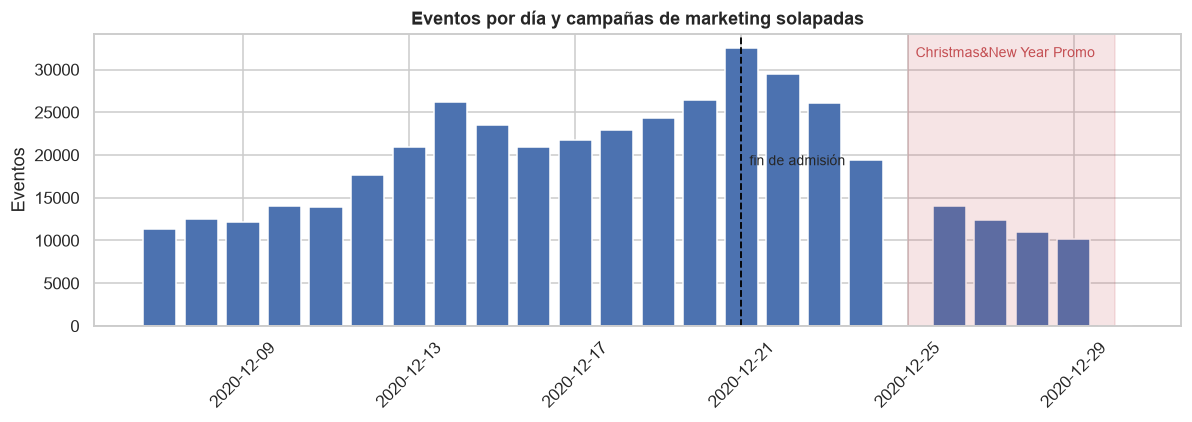

Días sin ningún evento dentro del período: ['2020-12-25']


In [7]:
activas = campanas[(campanas['start_dt'] <= '2021-01-01')
                   & (campanas['finish_dt'] >= '2020-12-07')
                   & campanas['regions'].str.contains('EU')]

print('Campañas de marketing solapadas con la prueba en la región EU:')
display(activas)

diario = eventos.groupby(eventos['event_dt'].dt.date).size()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(diario.index, diario.values, color=AZUL)
for _, c in activas.iterrows():
    ax.axvspan(c['start_dt'], min(c['finish_dt'], pd.Timestamp(diario.index.max())),
               color=ROJO, alpha=0.15)
    ax.text(c['start_dt'], ax.get_ylim()[1] * 0.92, '  ' + c['name'], color=ROJO, fontsize=9)
ax.axvline(pd.Timestamp('2020-12-21'), color='black', ls='--', lw=1.2)
ax.text(pd.Timestamp('2020-12-21'), ax.get_ylim()[1] * 0.55, '  fin de admisión', fontsize=9)
ax.set_title('Eventos por día y campañas de marketing solapadas')
ax.set_ylabel('Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

faltantes = (pd.date_range(diario.index.min(), diario.index.max())
             .difference(pd.to_datetime(diario.index)))
print(f'Días sin ningún evento dentro del período: {[str(d.date()) for d in faltantes]}')

## 2.1 Resultado de la auditoría

La prueba **incumple cinco de los seis parámetros de su propia especificación**:

1. **Reparto desequilibrado.** El grupo A casi triplica al B. Un reparto tan alejado del 50/50 es incompatible con una asignación aleatoria equilibrada, lo que apunta a un fallo en el mecanismo de asignación.
2. **Muestra insuficiente.** Se reclutaron 3 675 participantes frente a los 6 000 previstos.
3. **Audiencia contaminada geográficamente.** Hay participantes de N.America, APAC y CIS cuando la prueba debía limitarse a EU.
4. **Superposición entre pruebas.** Cientos de participantes están simultáneamente en `interface_eu_test`, de modo que reciben dos tratamientos a la vez y no puede saberse cuál explica su comportamiento.
5. **Datos truncados.** Los datos terminan el 30 de diciembre en lugar del 1 de enero, y además falta por completo el día 25. Solo el 55% de los participantes llega a tener los 14 días de seguimiento que la especificación exige.
6. **Confusor externo.** La campaña *Christmas & New Year Promo* se solapa con el tramo final de la prueba en la región EU, alterando el comportamiento de compra justo en el período de medición.

> **Conclusion**: Estos halazgos no dependen de ningún resultado de conversión la prueba ya está comprometida antes de medir nada. El análisis continúa para cuantificar la prueba realizada, pero la lectura de cualquier diferencia debe hacerse con esta advertencia presente.

---
# 3. Definición del universo de análisis

De los defectos detectados, dos son corregibles filtrando (participantes fuera de EU y contaminados por la otra prueba) y dos no lo son (el desequilibrio de grupos y el truncamiento temporal). Se aplican los filtros corregibles, documentando el coste en tamaño muestral.

In [8]:
pasos = [('Participantes de la prueba', prueba)]
paso = prueba[prueba['region'] == 'EU']
pasos.append(('Solo región EU', paso))
paso = paso[~paso['user_id'].isin(otro_test)]
pasos.append(('Sin contaminación de otra prueba', paso))

cascada = pd.DataFrame([
    {'Paso': nombre, 'Usuarios': len(df),
     'A': int((df['group'] == 'A').sum()), 'B': int((df['group'] == 'B').sum()),
     'Ratio A:B': round((df['group'] == 'A').sum() / max((df['group'] == 'B').sum(), 1), 2)}
    for nombre, df in pasos])
display(cascada)

analisis = pasos[-1][1].copy()
print(f'\nUniverso de análisis: {len(analisis):,} usuarios '
      f'({len(analisis)/len(prueba):.0%} de los participantes originales)')
print('El desequilibrio entre grupos persiste tras el filtrado: no es un artefacto de la contaminación.')

,Paso,Usuarios,A,B,Ratio A:B
0,Participantes de la prueba,3675,2747,928,2.96
1,Solo región EU,3481,2604,877,2.97
2,Sin contaminación de otra prueba,2594,1939,655,2.96



Universo de análisis: 2,594 usuarios (71% de los participantes originales)
El desequilibrio entre grupos persiste tras el filtrado: no es un artefacto de la contaminación.


In [9]:
ev_analisis = eventos.merge(
    analisis[['user_id', 'group', 'first_date', 'fin_ventana']], on='user_id', how='inner')

en_ventana = ((ev_analisis['event_dt'] >= ev_analisis['first_date'])
              & (ev_analisis['event_dt'] < ev_analisis['fin_ventana']))
ev14 = ev_analisis[en_ventana]

print(f'Eventos de los usuarios analizados : {len(ev_analisis):,}')
print(f'Dentro de la ventana de 14 días    : {len(ev14):,} ({len(ev14)/len(ev_analisis):.1%})')
print(f'Descartados por caer fuera         : {len(ev_analisis) - len(ev14):,}')

Eventos de los usuarios analizados : 16,959
Dentro de la ventana de 14 días    : 16,415 (96.8%)
Descartados por caer fuera         : 544


---
# 4. Análisis exploratorio del embudo

## 4.1 ¿Es el embudo realmente secuencial?

La especificación asume la secuencia `product_page → product_cart → purchase`. Conviene comprobar si los datos la respetan antes de calcular conversiones etapa a etapa.

In [10]:
por_usuario = ev14.groupby('user_id')['event_name'].agg(set)
compradores = por_usuario[por_usuario.apply(lambda s: 'purchase' in s)]

sin_carrito = compradores.apply(lambda s: 'product_cart' not in s).sum()
sin_pagina = compradores.apply(lambda s: 'product_page' not in s).sum()

print(f'Usuarios que compraron            : {len(compradores):,}')
print(f'  sin evento product_cart previo  : {sin_carrito:,} ({sin_carrito/len(compradores):.0%})')
print(f'  sin evento product_page previo  : {sin_pagina:,} ({sin_pagina/len(compradores):.0%})')

Usuarios que compraron            : 804
  sin evento product_cart previo  : 541 (67%)
  sin evento product_page previo  : 264 (33%)


**Conclusión** La mayoría de los compradores **no tiene un evento de carrito registrado**. El embudo no es secuencial en los datos: o el registro de eventos es incompleto, o existen rutas de compra que no pasan por el carrito.

La consecuencia práctica es que **no se pueden calcular conversiones etapa a etapa** (darían valores superiores al 100%, que carecen de sentido). Todas las conversiones de este análisis se calculan **sobre el total de usuarios de cada grupo**, que es una base bien definida y comparable entre A y B.

## 4.2 El embudo por grupo

In [11]:
def construir_embudo(usuarios_df, eventos_df):
    """Usuarios únicos que alcanzan cada etapa, y conversión sobre el total del grupo."""
    filas = {}
    for g in ['A', 'B']:
        n = usuarios_df.loc[usuarios_df['group'] == g, 'user_id'].nunique()
        sub = eventos_df[eventos_df['group'] == g]
        filas[g] = {'usuarios': n,
                    **{e: sub.loc[sub['event_name'] == e, 'user_id'].nunique() for e in ETAPAS}}
    return pd.DataFrame(filas).T

embudo = construir_embudo(analisis, ev14)
conversion = embudo[ETAPAS].div(embudo['usuarios'], axis=0)

print('Usuarios únicos que alcanzan cada etapa:')
display(embudo)
print('Conversión sobre el total del grupo:')
display((conversion * 100).round(1).astype(str) + '%')

Usuarios únicos que alcanzan cada etapa:


,usuarios,login,product_page,product_cart,purchase
A,1939,1939,1265,589,613
B,655,654,367,184,191


Conversión sobre el total del grupo:


,login,product_page,product_cart,purchase
A,100.0%,65.2%,30.4%,31.6%
B,99.8%,56.0%,28.1%,29.2%


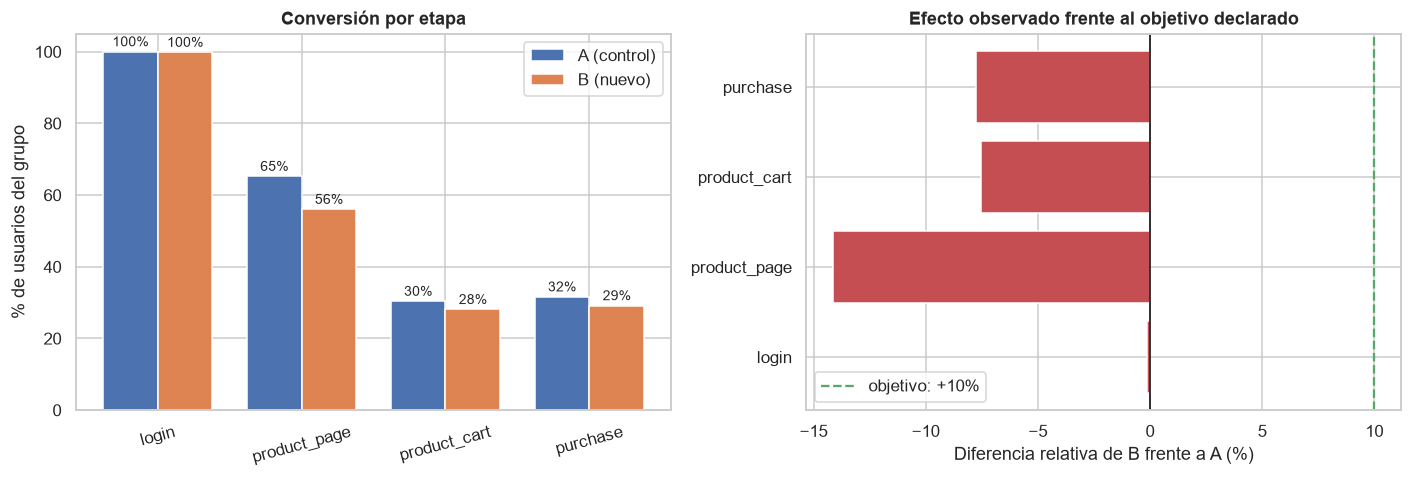

Diferencia relativa de B frente a A:
login            -0.2%
product_page    -14.1%
product_cart     -7.5%
purchase         -7.8%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(ETAPAS))
ancho = 0.38
axes[0].bar(x - ancho/2, conversion.loc['A'] * 100, ancho, label='A (control)', color=AZUL)
axes[0].bar(x + ancho/2, conversion.loc['B'] * 100, ancho, label='B (nuevo)', color=NARANJA)
axes[0].set_xticks(x, ETAPAS, rotation=15)
axes[0].set_ylabel('% de usuarios del grupo')
axes[0].set_title('Conversión por etapa')
axes[0].legend()
for i, (a, b) in enumerate(zip(conversion.loc['A'], conversion.loc['B'])):
    axes[0].text(i - ancho/2, a*100 + 1.5, f'{a:.0%}', ha='center', fontsize=9)
    axes[0].text(i + ancho/2, b*100 + 1.5, f'{b:.0%}', ha='center', fontsize=9)

lift = (conversion.loc['B'] / conversion.loc['A'] - 1) * 100
colores = [ROJO if v < 0 else '#55A868' for v in lift]
axes[1].barh(ETAPAS, lift, color=colores)
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(10, color='#55A868', ls='--', lw=1.5, label='objetivo: +10%')
axes[1].set_xlabel('Diferencia relativa de B frente a A (%)')
axes[1].set_title('Efecto observado frente al objetivo declarado')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Diferencia relativa de B frente a A:')
print(lift.round(1).astype(str).add('%').to_string())

**Conclusión** El grupo B no supera al A en ninguna etapa. En lugar del +10% esperado, todas las diferencias son **negativas**. El resultado más marcado está en `product_page`, la primera etapa tras el acceso.

## 4.3 Equilibrio de las muestras

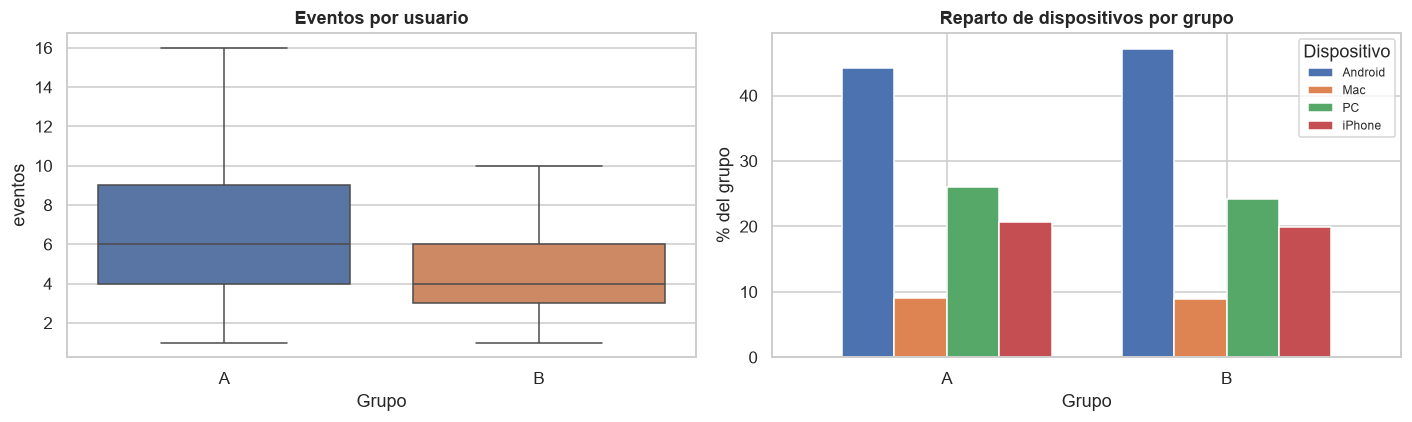

Eventos por usuario (mediana / media):
       median  mean
group              
A         6.0  6.67
B         4.0  5.32 

Reparto de dispositivos (%):
device  Android  Mac    PC  iPhone
group                             
A          44.2  9.1  26.0    20.6
B          47.2  8.9  24.1    19.8


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

por_usuario_n = ev14.groupby(['group', 'user_id']).size().rename('eventos').reset_index()
sns.boxplot(data=por_usuario_n, x='group', y='eventos', hue='group',
            palette={'A': AZUL, 'B': NARANJA}, legend=False, showfliers=False, ax=axes[0])
axes[0].set_title('Eventos por usuario')
axes[0].set_xlabel('Grupo')

disp = pd.crosstab(analisis['group'], analisis['device'], normalize='index') * 100
disp.plot(kind='bar', ax=axes[1], rot=0, width=0.75)
axes[1].set_title('Reparto de dispositivos por grupo')
axes[1].set_ylabel('% del grupo')
axes[1].set_xlabel('Grupo')
axes[1].legend(title='Dispositivo', fontsize=8)

plt.tight_layout()
plt.show()

print('Eventos por usuario (mediana / media):')
print(por_usuario_n.groupby('group')['eventos'].agg(['median', 'mean']).round(2).to_string(), '\n')
print('Reparto de dispositivos (%):')
print(disp.round(1).to_string())

**Conclusión** El reparto de dispositivos es prácticamente idéntico entre grupos, de modo que el desequilibrio no procede de ahí. En cambio, los usuarios del grupo B generan menos eventos por persona: son **menos activos en general**, no solo en una etapa concreta del embudo.

---
# 5. Evaluación estadística

## 5.1 Prueba z para la diferencia de proporciones

Para cada etapa se contrasta:

> **H₀:** la proporción de usuarios que alcanzan la etapa es igual en A y en B.
> **H₁:** las proporciones difieren.

Se realizan tres contrastes sobre los mismos datos, de modo que se aplica la **corrección de Holm** para controlar el error de tipo I acumulado. Nivel de significación **α = 0,05**.

In [14]:
def evaluar_embudo(embudo_df, etiqueta=''):
    conv = embudo_df[ETAPAS].div(embudo_df['usuarios'], axis=0)
    filas, p_brutos = [], []
    for etapa in ETAPAS[1:]:
        exitos = np.array([embudo_df.loc['B', etapa], embudo_df.loc['A', etapa]])
        tam = np.array([embudo_df.loc['B', 'usuarios'], embudo_df.loc['A', 'usuarios']])
        z, p = proportions_ztest(exitos, tam)
        p_brutos.append(p)
        pa, pb = conv.loc['A', etapa], conv.loc['B', etapa]
        # intervalo de confianza al 95% para la diferencia absoluta (B - A)
        se = np.sqrt(pa * (1 - pa) / tam[1] + pb * (1 - pb) / tam[0])
        dif = pb - pa
        filas.append({'Etapa': etapa, 'Conv. A': f'{pa:.1%}', 'Conv. B': f'{pb:.1%}',
                      'Dif. absoluta': f'{dif:+.1%}',
                      'IC 95%': f'[{dif - 1.96*se:+.1%}, {dif + 1.96*se:+.1%}]',
                      'Dif. relativa': f'{pb/pa - 1:+.1%}',
                      'z': round(z, 3), 'p': p})
    rechaza, ajustados, _, _ = multipletests(p_brutos, alpha=ALFA, method='holm')
    tabla = pd.DataFrame(filas)
    tabla['p (Holm)'] = ajustados.round(4)
    tabla['Decisión'] = np.where(rechaza, 'Se rechaza H0', 'No se rechaza H0')
    tabla['p'] = tabla['p'].round(4)
    if etiqueta:
        print(etiqueta)
    return tabla

resultados = evaluar_embudo(embudo)
resultados

,Etapa,Conv. A,Conv. B,Dif. absoluta,IC 95%,Dif. relativa,z,p,p (Holm),Decisión
0,product_page,65.2%,56.0%,-9.2%,"[-13.6%, -4.9%]",-14.1%,-4.219,0.0000,0.0001,Se rechaza H0
1,product_cart,30.4%,28.1%,-2.3%,"[-6.3%, +1.7%]",-7.5%,-1.105,0.2690,0.4807,No se rechaza H0
2,purchase,31.6%,29.2%,-2.5%,"[-6.5%, +1.6%]",-7.8%,-1.174,0.2404,0.4807,No se rechaza H0


**Lectura.** Solo `product_page` arroja una diferencia estadísticamente significativa, y es **desfavorable al grupo B**. En `product_cart` y `purchase` no se rechaza la hipótesis nula.

Ahora bien, "no se rechaza H₀" no significa "no hay diferencia". Puede significar simplemente que la muestra era demasiado pequeña para detectarla. Esa es la pregunta de la siguiente sección.

## 5.2 ¿Podía esta prueba detectar el efecto que buscaba?

Se calcula el tamaño de muestra necesario para detectar el **+10% relativo** que la especificación exigía, con una potencia estándar del 80%, y se compara con el tamaño realmente disponible.

In [15]:
potencia = NormalIndPower()
n_a = embudo.loc['A', 'usuarios']
n_b = embudo.loc['B', 'usuarios']

filas = []
for etapa in ETAPAS[1:]:
    p_control = conversion.loc['A', etapa]
    p_objetivo = p_control * 1.10
    efecto = proportion_effectsize(p_objetivo, p_control)
    n_necesario = potencia.solve_power(effect_size=efecto, alpha=ALFA, power=0.80,
                                       ratio=1.0, alternative='two-sided')
    pot_real = potencia.solve_power(effect_size=efecto, nobs1=n_b, alpha=ALFA,
                                    ratio=n_a / n_b, alternative='two-sided')
    filas.append({'Etapa': etapa,
                  'Conv. control': f'{p_control:.1%}',
                  'Objetivo (+10%)': f'{p_objetivo:.1%}',
                  'n necesario por grupo': f'{n_necesario:,.0f}',
                  'n real en B': f'{n_b:,}',
                  'Potencia alcanzada': f'{pot_real:.0%}'})

pd.DataFrame(filas)

,Etapa,Conv. control,Objetivo (+10%),n necesario por grupo,n real en B,Potencia alcanzada
0,product_page,65.2%,71.8%,794,655,88%
1,product_cart,30.4%,33.4%,"3,694",655,30%
2,purchase,31.6%,34.8%,"3,481",655,32%


**Conclusión.** Para detectar una mejora del 10% en el carrito o en la compra harían falta del orden de **3 500 a 3 700 usuarios por grupo**. El grupo B tuvo 655.

La potencia real en esas dos etapas ronda el 30%: aunque el nuevo sistema de recomendaciones hubiera funcionado exactamente como se esperaba, **esta prueba habría fallado en detectarlo unas siete de cada diez veces**. La ausencia de significación en `product_cart` y `purchase` no es evidencia de que el tratamiento no funcione; es evidencia de que **la prueba no estaba dimensionada para responder a su propia pregunta**.

Conviene notar que el tamaño previsto en la especificación —6 000 participantes, unos 3 000 por grupo— tampoco habría bastado.

---
# 6. Comprobación de robustez

El resultado anterior podría estar contaminado por el truncamiento temporal: casi la mitad de los usuarios no llegó a completar sus 14 días de seguimiento. Se repite el análisis **solo con quienes sí tuvieron la ventana completa**. Si las conclusiones se mantienen, no dependen de ese defecto.

In [16]:
completos = analisis[analisis['fin_ventana'] <= ultimo_evento]
ev_completos = ev14[ev14['user_id'].isin(completos['user_id'])]

embudo_rob = construir_embudo(completos, ev_completos)
conv_rob = embudo_rob[ETAPAS].div(embudo_rob['usuarios'], axis=0)

print(f'Usuarios con ventana de 14 días completa: {len(completos):,} '
      f'(A={int((completos["group"]=="A").sum())}, B={int((completos["group"]=="B").sum())})\n')
display(evaluar_embudo(embudo_rob))

comparativa = pd.DataFrame({
    'Análisis principal': conversion.loc['B'] / conversion.loc['A'] - 1,
    'Solo ventana completa': conv_rob.loc['B'] / conv_rob.loc['A'] - 1,
})
print('Diferencia relativa de B frente a A en ambos análisis:')
(comparativa * 100).round(1).astype(str) + '%'

Usuarios con ventana de 14 días completa: 1,419 (A=969, B=450)



,Etapa,Conv. A,Conv. B,Dif. absoluta,IC 95%,Dif. relativa,z,p,p (Holm),Decisión
0,product_page,64.3%,56.2%,-8.1%,"[-13.6%, -2.6%]",-12.6%,-2.911,0.0036,0.0108,Se rechaza H0
1,product_cart,31.0%,27.8%,-3.2%,"[-8.2%, +1.9%]",-10.3%,-1.218,0.2233,0.4466,No se rechaza H0
2,purchase,29.5%,27.6%,-2.0%,"[-7.0%, +3.1%]",-6.6%,-0.758,0.4486,0.4486,No se rechaza H0


Diferencia relativa de B frente a A en ambos análisis:


,Análisis principal,Solo ventana completa
login,-0.2%,-0.2%
product_page,-14.1%,-12.6%
product_cart,-7.5%,-10.3%
purchase,-7.8%,-6.6%


**Conclusion.** Los hallazgos se mantienen: el grupo B sigue por detrás en todas las etapas y la única diferencia significativa continúa siendo la de `product_page`, desfavorable a B. El resultado **no es un artefacto del truncamiento temporal**.

---
# 7. Conclusiones y recomendación

In [17]:
print('=' * 70)
print('RESUMEN EJECUTIVO — recommender_system_test'.center(70))
print('=' * 70)
print(f'Participantes declarados en la prueba : {len(prueba):,} (previstos: 6 000)')
print(f'Universo analizable tras depuración   : {len(analisis):,} '
      f'(A={n_a:,} / B={n_b:,})')
print(f'Parámetros de la especificación incumplidos: 5 de 6')
print('-' * 70)
print('Resultado por etapa (B frente a A):')
for etapa in ETAPAS[1:]:
    dif = conversion.loc['B', etapa] / conversion.loc['A', etapa] - 1
    print(f'  {etapa:<14} {dif:+6.1%}   (objetivo declarado: +10%)')
print('-' * 70)
print('Ninguna etapa alcanza el objetivo. La única diferencia significativa')
print('es desfavorable al grupo B. Las etapas de carrito y compra carecen')
print('de potencia estadística suficiente para concluir nada.')
print('=' * 70)

             RESUMEN EJECUTIVO — recommender_system_test              
Participantes declarados en la prueba : 3,675 (previstos: 6 000)
Universo analizable tras depuración   : 2,594 (A=1,939 / B=655)
Parámetros de la especificación incumplidos: 5 de 6
----------------------------------------------------------------------
Resultado por etapa (B frente a A):
  product_page   -14.1%   (objetivo declarado: +10%)
  product_cart    -7.5%   (objetivo declarado: +10%)
  purchase        -7.8%   (objetivo declarado: +10%)
----------------------------------------------------------------------
Ninguna etapa alcanza el objetivo. La única diferencia significativa
es desfavorable al grupo B. Las etapas de carrito y compra carecen
de potencia estadística suficiente para concluir nada.


## 7.1 Conclusiones

**Sobre la ejecución de la prueba**

1. La prueba **incumple cinco de los seis parámetros de su especificación**: muestra insuficiente, grupos desequilibrados casi 3:1, participantes fuera de la región objetivo, contaminación con una segunda prueba simultánea y período de observación truncado.
2. Además coincide con una **campaña de marketing navideña** en la misma región, que altera el comportamiento de compra justo en el tramo final del período de medición.
3. Los datos revelan un **problema de instrumentación**: la mayoría de los compradores no tiene registrado el evento de carrito, de modo que el embudo declarado no se corresponde con el que los datos describen.

**Sobre el resultado**

4. El grupo B **no supera al grupo A en ninguna etapa**. Frente al +10% esperado, todas las diferencias observadas son negativas.
5. La única diferencia estadísticamente significativa está en `product_page` y es **desfavorable al nuevo sistema**. Se mantiene al repetir el análisis solo con usuarios de ventana completa, así que no es un artefacto del truncamiento.
6. En `product_cart` y `purchase` **no se puede concluir nada**: la potencia estadística alcanzada ronda el 30%, muy por debajo del 80% habitual. Harían falta unos 3 500 usuarios por grupo y hubo 655.

## 7.2 Recomendación

> **No adoptar el nuevo sistema de recomendaciones, y no descartarlo tampoco: repetir la prueba correctamente.**

El único resultado sólido —el retroceso en `product_page`— es motivo suficiente para no desplegar el cambio tal como está. Pero declarar que el sistema "no funciona" sería un error simétrico: en las etapas que de verdad importan para el negocio, la prueba nunca tuvo capacidad de detectar el efecto que buscaba.

**Condiciones para una repetición válida**

| # | Condición | Motivo |
|---|---|---|
| 1 | Al menos 3 500 usuarios por grupo | Es el mínimo para detectar un +10% en compra con potencia del 80% |
| 2 | Verificar el equilibrio de la asignación antes de lanzar | El reparto 3:1 observado indica un fallo en el mecanismo de asignación |
| 3 | Excluir a los usuarios inscritos en otras pruebas | Evita atribuir a un tratamiento el efecto de otro |
| 4 | Filtrar la audiencia por región en el momento de la asignación | La prueba debía limitarse a EU y no lo hizo |
| 5 | Garantizar 14 días completos de datos para el último usuario admitido | Exige mantener la recogida al menos dos semanas tras el cierre de admisión |
| 6 | Evitar el solapamiento con campañas de marketing en la región | Elimina el confusor navideño |
| 7 | Auditar el registro del evento `product_cart` | Sin instrumentación fiable, el embudo no es medible |

**Coste de no hacerlo:** desplegar el sistema apoyándose en esta prueba significaría tomar una decisión de producto sobre evidencia que no la sostiene, en cualquiera de las dos direcciones.

## 7.3 Limitaciones del propio análisis

- El desequilibrio entre grupos no es corregible a posteriori. Si el mecanismo que lo provocó también sesgó **qué** usuarios entraron en cada grupo, las diferencias observadas podrían reflejar ese sesgo y no el tratamiento.
- Las conversiones se calculan sobre el total del grupo y no etapa a etapa, por la falta de secuencialidad del embudo registrado.
- El período analizado incluye la campaña navideña; no es posible aislar su efecto con los datos disponibles.

---
# 8. Fuentes consultadas

| # | Fuente | Qué pregunta ayudó a resolver |
|---|---|---|
| 1 | [statsmodels — `proportions_ztest`](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html) | Cómo contrastar la diferencia entre dos proporciones independientes y qué devuelve exactamente el estadístico |
| 2 | [statsmodels — `NormalIndPower`](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.NormalIndPower.html) y [`proportion_effectsize`](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportion_effectsize.html) | Cómo calcular el tamaño de muestra necesario y la potencia alcanzada con grupos de distinto tamaño |
| 3 | [statsmodels — `multipletests`](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html) | Cómo corregir el nivel de significación al contrastar tres etapas sobre los mismos datos |
| 4 | [Kohavi, Tang & Xu — *Trustworthy Online Controlled Experiments*](https://experimentguide.com/) | Qué comprobaciones de validez debe superar un experimento antes de interpretar sus resultados |
| 5 | [Sample Ratio Mismatch — Microsoft Experimentation Platform](https://www.microsoft.com/en-us/research/group/experimentation-platform-exp/articles/diagnosing-sample-ratio-mismatch-in-a-b-testing/) | Por qué un reparto desequilibrado entre grupos invalida un experimento y cómo diagnosticarlo |
| 6 | [Cohen, J. — *Statistical Power Analysis*](https://doi.org/10.1037/0033-2909.112.1.155) | Por qué una potencia del 80% es el estándar y cómo interpretar un resultado no significativo con potencia baja |
| 7 | [pandas — `merge` y validación de uniones](https://pandas.pydata.org/docs/user_guide/merging.html) | Cómo unir participantes, eventos y fichas de registro sin duplicar filas por coincidencias múltiples |
| 8 | [Holm, S. (1979). *A Simple Sequentially Rejective Multiple Test Procedure*](https://www.jstor.org/stable/4615733) | Por qué Holm controla el error de tipo I con más potencia que Bonferroni |